# 🚢 Titanic - Machine Learning from Disaster
## Phase 12: Advanced Group Intelligence, Nested Cross-Fitting & Robust Competition Optimization

### Objective

Our Kaggle competition performance has improved significantly:

| Phase | Submission | Kaggle Public Score |
|---|---|---:|
| Phase 9 | Random Forest | 0.75119 |
| Phase 10 | Robust Model | 0.77990 |
| Phase 11 | Best Individual | 0.79186 |
| Phase 11 | Group Ensemble | **0.81339** |
| Phase 11 | Group Hybrid | **0.81339** |
| Phase 11 | Demographic Hybrid | **0.81339** |

Phase 11 revealed an important pattern:

> Family and ticket-group relationships contain valuable survival information.

The objective of Phase 12 is to improve how we model these relationships while making our validation methodology more rigorous.

---

# Phase 12 Strategy

We will focus on:

1. Rebuilding strong structural passenger features.
2. Creating improved family and ticket group identifiers.
3. Creating demographic-aware group relationships.
4. Generating target-derived group features independently inside each validation fold.
5. Avoiding self-target leakage.
6. Comparing base models against group-intelligence models.
7. Testing probability ensembles.
8. Analyzing model disagreement.
9. Applying only OOF-supported post-processing rules.
10. Generating a small number of genuinely distinct competition submissions.

---

# Key Methodological Improvement

Phase 11 used cross-fitted target features.

However, those features were generated once before the final model cross-validation.

Phase 12 improves this using:

## Nested Cross-Fitting

For every outer validation fold:

1. Split passengers into outer training and validation sets.
2. Use only outer-training labels to calculate group survival statistics.
3. Map those statistics to outer-validation passengers.
4. Train the model on outer-training passengers.
5. Predict outer-validation passengers.

The validation passenger's target is never used when creating their group intelligence features.

This gives us a more realistic estimate of whether group survival patterns generalize.

---

# Current Benchmark

Our Kaggle score to beat is:

**0.81339**

The goal of Phase 12 is to improve beyond this benchmark using reproducible, leakage-controlled machine learning.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from copy import deepcopy

from sklearn.model_selection import StratifiedKFold

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.base import clone

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    classification_report
)

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Define Project Paths

Phase 12 will rebuild all features from the original Kaggle datasets.

This ensures that:

- Feature engineering is reproducible.
- Group relationships are constructed consistently.
- Target-derived features are handled separately from target-free structural features.

In [3]:
raw_data_dir = Path("../data/raw")

results_dir = Path("../results")

submissions_dir = Path("../submissions")

models_dir = Path("../models")


results_dir.mkdir(
    parents=True,
    exist_ok=True
)

submissions_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)


print("Project directories configured.")

Project directories configured.


In [4]:
train_raw = pd.read_csv(
    raw_data_dir / "train.csv"
)

test_raw = pd.read_csv(
    raw_data_dir / "test.csv"
)


print(
    f"Training shape: {train_raw.shape}"
)

print(
    f"Test shape: {test_raw.shape}"
)


assert "Survived" in train_raw.columns

assert "Survived" not in test_raw.columns

assert train_raw["PassengerId"].is_unique

assert test_raw["PassengerId"].is_unique


y = train_raw[
    "Survived"
].astype(int).copy()


test_passenger_ids = test_raw[
    "PassengerId"
].copy()


train_raw.head()

Training shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Create Target-Free Structural Features

Train and test passengers will temporarily be combined.

This allows us to calculate structural information such as:

- Total ticket group size.
- Family manifest size.
- Shared ticket status.
- Family identifiers.

No survival labels are used during this stage.

Therefore, these structural features are available independently of the target variable.

In [5]:
train_base = train_raw.drop(
    columns=["Survived"]
).copy()


test_base = test_raw.copy()


train_base["Dataset"] = "train"

test_base["Dataset"] = "test"


combined = pd.concat(

    [
        train_base,
        test_base
    ],

    ignore_index=True
)


print(
    f"Combined manifest shape: "
    f"{combined.shape}"
)

Combined manifest shape: (1309, 12)


In [7]:
combined["Title"] = (

    combined["Name"]

    .str.extract(
        r",\s*([^.]*)\."
    )[0]

    .str.strip()
)


title_mapping = {

    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",

    "Lady": "Rare",
    "Countess": "Rare",
    "Capt": "Rare",
    "Col": "Rare",
    "Don": "Rare",
    "Dr": "Rare",
    "Major": "Rare",
    "Rev": "Rare",
    "Sir": "Rare",
    "Jonkheer": "Rare",
    "Dona": "Rare",
    "the Countess": "Rare"
}


combined["Title"] = (

    combined["Title"]

    .replace(
        title_mapping
    )
)


combined[
    "Title"
].value_counts()

Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64

In [8]:
combined["Surname"] = (

    combined["Name"]

    .str.split(",")

    .str[0]

    .str.strip()

    .str.upper()
)


combined[
    [
        "Name",
        "Surname"
    ]
].head()

,Name,Surname
0,"Braund, Mr. Owen Harris",BRAUND
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",CUMINGS
2,"Heikkinen, Miss. Laina",HEIKKINEN
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",FUTRELLE
4,"Allen, Mr. William Henry",ALLEN


In [9]:
combined["FamilySize"] = (

    combined["SibSp"]

    +

    combined["Parch"]

    +

    1
)


combined["IsAlone"] = (

    combined["FamilySize"]
    == 1

).astype(int)


combined["FamilyCategory"] = pd.cut(

    combined["FamilySize"],

    bins=[
        0,
        1,
        4,
        7,
        np.inf
    ],

    labels=[
        "Alone",
        "Small",
        "Medium",
        "Large"
    ]
)

# 4. Construct Multiple Family Identifiers

A single definition of family may not capture every relationship.

We will create two family identifiers.

### FamilyID

`Surname + FamilySize`

This is our primary family identifier.

### SurnameGroup

Uses surname alone.

Surname groups are broader and potentially noisier, but they may identify extended family relationships that `FamilyID` misses.

We will use these identifiers for group analysis rather than directly one-hot encoding them.

In [10]:
combined["FamilyID"] = (

    combined["Surname"]

    +

    "_"

    +

    combined[
        "FamilySize"
    ].astype(str)
)


family_counts = (

    combined[
        "FamilyID"
    ]

    .value_counts()
)


surname_counts = (

    combined[
        "Surname"
    ]

    .value_counts()
)


combined[
    "FamilyManifestSize"
] = (

    combined[
        "FamilyID"
    ]

    .map(
        family_counts
    )
)


combined[
    "SurnameGroupSize"
] = (

    combined[
        "Surname"
    ]

    .map(
        surname_counts
    )
)

In [11]:
combined["TicketClean"] = (

    combined["Ticket"]

    .astype(str)

    .str.upper()

    .str.replace(
        r"\s+",
        "",
        regex=True
    )

    .str.strip()
)


ticket_counts = (

    combined[
        "TicketClean"
    ]

    .value_counts()
)


combined[
    "TicketGroupSize"
] = (

    combined[
        "TicketClean"
    ]

    .map(
        ticket_counts
    )
)


combined["SharedTicket"] = (

    combined[
        "TicketGroupSize"
    ]
    > 1

).astype(int)


combined["TicketPrefix"] = (

    combined["Ticket"]

    .astype(str)

    .str.upper()

    .str.replace(
        r"\d",
        "",
        regex=True
    )

    .str.replace(
        r"[\s./]",
        "",
        regex=True
    )

    .replace(
        "",
        "NONE"
    )
)

# 5. Improved Age Imputation

Age is strongly associated with:

- Title.
- Passenger class.
- Sex.

We will therefore impute missing ages using the median age of passengers sharing:

`Title + Pclass + Sex`

If no suitable group median is available, we fall back to the global median.

In [12]:
combined[
    "AgeMissing"
] = (

    combined[
        "Age"
    ]

    .isna()

).astype(int)


age_group_median = (

    combined

    .groupby(

        [
            "Title",
            "Pclass",
            "Sex"
        ]

    )[
        "Age"
    ]

    .transform(
        "median"
    )
)


combined["Age"] = (

    combined["Age"]

    .fillna(
        age_group_median
    )

    .fillna(

        combined[
            "Age"
        ].median()
    )
)

In [13]:
combined["AgeBand"] = pd.cut(

    combined["Age"],

    bins=[
        -np.inf,
        5,
        12,
        16,
        25,
        40,
        60,
        np.inf
    ],

    labels=[
        "Baby",
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "MiddleAge",
        "Senior"
    ]
)

# 6. Create Demographic Roles

Phase 12 introduces a `DemographicRole` feature.

Passengers will be categorized into broad Titanic-relevant demographic groups:

- Woman
- Girl
- Boy
- AdultMale

This allows us to investigate whether group survival information should be interpreted differently depending on the passenger being predicted.

In [14]:
combined["Child"] = (

    combined["Age"]
    < 16

).astype(int)


combined["YoungChild"] = (

    combined["Age"]
    < 10

).astype(int)


combined["Woman"] = (

    (
        combined["Sex"]
        == "female"
    )

    &

    (
        combined["Age"]
        >= 16
    )

).astype(int)


combined["Girl"] = (

    (
        combined["Sex"]
        == "female"
    )

    &

    (
        combined["Age"]
        < 16
    )

).astype(int)


combined["Boy"] = (

    (
        combined["Sex"]
        == "male"
    )

    &

    (
        combined["Age"]
        < 16
    )

).astype(int)


combined["AdultMale"] = (

    (
        combined["Sex"]
        == "male"
    )

    &

    (
        combined["Age"]
        >= 16
    )

).astype(int)


combined["Mother"] = (

    (
        combined["Sex"]
        == "female"
    )

    &

    (
        combined["Age"]
        > 18
    )

    &

    (
        combined["Parch"]
        > 0
    )

    &

    (
        combined["Title"]
        != "Miss"
    )

).astype(int)

In [15]:
combined["DemographicRole"] = "AdultMale"


combined.loc[

    combined[
        "Woman"
    ]
    == 1,

    "DemographicRole"

] = "Woman"


combined.loc[

    combined[
        "Girl"
    ]
    == 1,

    "DemographicRole"

] = "Girl"


combined.loc[

    combined[
        "Boy"
    ]
    == 1,

    "DemographicRole"

] = "Boy"


combined[
    "DemographicRole"
].value_counts()

DemographicRole
AdultMale    776
Woman        410
Boy           67
Girl          56
Name: count, dtype: int64

In [16]:
combined["Fare"] = (

    combined["Fare"]

    .fillna(

        combined[
            "Fare"
        ].median()
    )
)


combined["FarePerPerson"] = (

    combined["Fare"]

    /

    combined[
        "TicketGroupSize"
    ]
)


combined["LogFare"] = (

    np.log1p(

        combined[
            "Fare"
        ]
    )
)

In [17]:
combined["CabinKnown"] = (

    combined["Cabin"]

    .notna()

).astype(int)


combined["Deck"] = (

    combined["Cabin"]

    .fillna(
        "Unknown"
    )

    .astype(str)

    .str[0]
)

In [18]:
combined["Sex_Pclass"] = (

    combined["Sex"].astype(str)

    +

    "_"

    +

    combined["Pclass"].astype(str)
)


combined["Title_Pclass"] = (

    combined["Title"].astype(str)

    +

    "_"

    +

    combined["Pclass"].astype(str)
)


combined["Role_Pclass"] = (

    combined[
        "DemographicRole"
    ].astype(str)

    +

    "_"

    +

    combined[
        "Pclass"
    ].astype(str)
)


combined["FamilyClass"] = (

    combined[
        "FamilyCategory"
    ].astype(str)

    +

    "_"

    +

    combined[
        "Pclass"
    ].astype(str)
)

In [19]:
train_struct = (

    combined[

        combined[
            "Dataset"
        ]
        == "train"

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


test_struct = (

    combined[

        combined[
            "Dataset"
        ]
        == "test"

    ]

    .copy()

    .reset_index(
        drop=True
    )
)


assert len(
    train_struct
) == len(
    train_raw
)


assert len(
    test_struct
) == len(
    test_raw
)


print(
    train_struct.shape,
    test_struct.shape
)

(891, 42) (418, 42)


In [20]:
base_features = [

    "Pclass",
    "Sex",
    "Age",
    "AgeBand",

    "SibSp",
    "Parch",

    "Fare",
    "Embarked",

    "Title",

    "FamilySize",
    "IsAlone",
    "FamilyCategory",
    "FamilyManifestSize",
    "SurnameGroupSize",

    "TicketGroupSize",
    "SharedTicket",
    "TicketPrefix",

    "CabinKnown",
    "Deck",

    "FarePerPerson",
    "LogFare",

    "AgeMissing",

    "Child",
    "YoungChild",

    "Woman",
    "Girl",
    "Boy",
    "AdultMale",
    "Mother",

    "DemographicRole",

    "Sex_Pclass",
    "Title_Pclass",
    "Role_Pclass",
    "FamilyClass"
]


print(
    f"Base structural features: "
    f"{len(base_features)}"
)

Base structural features: 34


# 7. Leakage-Controlled Group Statistics

We now define a function that calculates smoothed group survival statistics.

For a group with:

- `n` known members.
- Mean survival `m`.
- Global survival rate `g`.

The smoothed estimate is:

`(m × n + g × smoothing) / (n + smoothing)`

Smoothing prevents very small groups from producing extreme survival estimates.

For example, one known survivor should not automatically imply a 100% survival probability for every related passenger.

In [21]:
def build_group_mapping(
    reference_df,
    reference_y,
    group_column,
    smoothing=3.0
):

    temp = reference_df[
        [
            group_column
        ]
    ].copy()


    temp["_target_"] = (

        np.asarray(
            reference_y
        )
    )


    global_mean = (

        temp[
            "_target_"
        ].mean()
    )


    stats = (

        temp

        .groupby(
            group_column
        )[
            "_target_"
        ]

        .agg(
            [
                "mean",
                "count"
            ]
        )
    )


    stats[
        "smoothed"
    ] = (

        (

            stats[
                "mean"
            ]

            *

            stats[
                "count"
            ]

        )

        +

        (

            global_mean

            *

            smoothing

        )

    ) / (

        stats[
            "count"
        ]

        +

        smoothing
    )


    return (
        stats,
        global_mean
    )

In [22]:
def map_group_statistics(
    target_df,
    group_column,
    stats,
    global_mean
):

    signal = (

        target_df[
            group_column
        ]

        .map(
            stats[
                "smoothed"
            ]
        )

        .fillna(
            global_mean
        )

        .astype(float)
    )


    count = (

        target_df[
            group_column
        ]

        .map(
            stats[
                "count"
            ]
        )

        .fillna(
            0
        )

        .astype(float)
    )


    return (
        signal.values,
        count.values
    )

# 8. Demographic-Aware Group Intelligence

A simple ticket survival rate treats every passenger in a group identically.

However, survival patterns differed substantially between demographic groups.

We will therefore create an additional concept:

## Protected Group

Passengers classified as:

- Woman
- Girl
- Boy

will be treated as a broad protected demographic group.

Adult men will form the second group.

This allows us to calculate group statistics such as:

- Survival of protected members within a family.
- Survival of protected members sharing a ticket.
- Survival of adult male members within a group.

These signals may provide more relevant information than the survival rate of all group members combined.

In [23]:
train_struct[
    "ProtectedGroup"
] = np.where(

    train_struct[
        "DemographicRole"
    ].isin(
        [
            "Woman",
            "Girl",
            "Boy"
        ]
    ),

    "Protected",

    "AdultMale"
)


test_struct[
    "ProtectedGroup"
] = np.where(

    test_struct[
        "DemographicRole"
    ].isin(
        [
            "Woman",
            "Girl",
            "Boy"
        ]
    ),

    "Protected",

    "AdultMale"
)

# 9. Build Group Intelligence Inside Each Fold

This function creates target-derived features using only a provided reference dataset.

The following group signals will be generated:

1. Family survival signal.
2. Ticket survival signal.
3. Surname survival signal.
4. Demographic-family survival signal.
5. Demographic-ticket survival signal.

The demographic group keys combine:

`FamilyID + ProtectedGroup`

and:

`TicketClean + ProtectedGroup`

This allows group statistics to distinguish between protected passengers and adult men.

In [24]:
def add_group_keys(df):

    df = df.copy()


    df[
        "FamilyProtectedKey"
    ] = (

        df[
            "FamilyID"
        ].astype(str)

        +

        "__"

        +

        df[
            "ProtectedGroup"
        ].astype(str)
    )


    df[
        "TicketProtectedKey"
    ] = (

        df[
            "TicketClean"
        ].astype(str)

        +

        "__"

        +

        df[
            "ProtectedGroup"
        ].astype(str)
    )


    return df


train_struct = add_group_keys(
    train_struct
)


test_struct = add_group_keys(
    test_struct
)

In [25]:
GROUP_DEFINITIONS = {

    "Family":
        "FamilyID",

    "Ticket":
        "TicketClean",

    "Surname":
        "Surname",

    "FamilyProtected":
        "FamilyProtectedKey",

    "TicketProtected":
        "TicketProtectedKey"
}

In [26]:
def add_target_group_features(
    reference_df,
    reference_y,
    target_df,
    smoothing=3.0
):

    output = target_df.copy()


    for feature_name, group_column in (
        GROUP_DEFINITIONS.items()
    ):

        stats, global_mean = (

            build_group_mapping(

                reference_df,

                reference_y,

                group_column,

                smoothing=smoothing
            )
        )


        signal, count = (

            map_group_statistics(

                output,

                group_column,

                stats,

                global_mean
            )
        )


        output[
            f"{feature_name}SurvivalSignal"
        ] = signal


        output[
            f"{feature_name}KnownCount"
        ] = count


        output[
            f"{feature_name}SignalAvailable"
        ] = (

            count > 0

        ).astype(int)


    return output

In [27]:
target_group_features = []


for group_name in (
    GROUP_DEFINITIONS.keys()
):

    target_group_features.extend(

        [

            f"{group_name}SurvivalSignal",

            f"{group_name}KnownCount",

            f"{group_name}SignalAvailable"
        ]
    )


advanced_features = (

    base_features

    +

    target_group_features
)


print(
    f"Advanced feature count: "
    f"{len(advanced_features)}"
)

Advanced feature count: 49


In [28]:
categorical_features = [

    "Pclass",
    "Sex",
    "AgeBand",
    "Embarked",
    "Title",

    "FamilyCategory",

    "TicketPrefix",

    "Deck",

    "DemographicRole",

    "Sex_Pclass",
    "Title_Pclass",
    "Role_Pclass",
    "FamilyClass"
]

In [29]:
def create_preprocessor(
    feature_list
):

    categorical = [

        feature

        for feature
        in feature_list

        if feature
        in categorical_features
    ]


    numerical = [

        feature

        for feature
        in feature_list

        if feature
        not in categorical
    ]


    numeric_pipeline = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",

                StandardScaler()
            )
        ]
    )


    categorical_pipeline = Pipeline(

        steps=[

            (
                "imputer",

                SimpleImputer(
                    strategy="most_frequent"
                )
            ),

            (
                "onehot",

                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    return ColumnTransformer(

        transformers=[

            (
                "numeric",

                numeric_pipeline,

                numerical
            ),

            (
                "categorical",

                categorical_pipeline,

                categorical
            )
        ]
    )

# 10. Candidate Models

Phase 12 will compare four model families.

### Logistic Regression

Provides a regularized linear baseline and often generalizes well on small tabular datasets.

### Random Forest

Captures nonlinear feature interactions.

### Extra Trees

Introduces additional randomization and may capture different decision boundaries from Random Forest.

### Gradient Boosting

Sequentially models residual errors and can capture complex relationships using relatively shallow trees.

The objective is not simply to select the model with the highest single-fold accuracy.

We will compare:

- Overall OOF accuracy.
- OOF log loss.
- Fold stability.
- Model disagreement.

In [30]:
candidate_models = {

    "Logistic Regression":

        LogisticRegression(

            C=0.25,

            max_iter=5000,

            random_state=42
        ),


    "Random Forest":

        RandomForestClassifier(

            n_estimators=1200,

            max_depth=6,

            min_samples_split=6,

            min_samples_leaf=3,

            max_features="sqrt",

            random_state=42,

            n_jobs=-1
        ),


    "Extra Trees":

        ExtraTreesClassifier(

            n_estimators=1200,

            max_depth=7,

            min_samples_split=6,

            min_samples_leaf=3,

            max_features="sqrt",

            random_state=42,

            n_jobs=-1
        ),


    "Gradient Boosting":

        GradientBoostingClassifier(

            n_estimators=180,

            learning_rate=0.025,

            max_depth=3,

            min_samples_leaf=5,

            subsample=0.85,

            random_state=42
        )
}

# 11. Nested Group-Feature Cross-Validation

This is the central validation experiment in Phase 12.

For each outer fold:

### Step 1

Separate passengers into outer training and validation sets.

### Step 2

Calculate all target-derived family and ticket statistics using only outer-training labels.

### Step 3

Generate group features for:

- Outer-training passengers.
- Outer-validation passengers.

For outer-training passengers, a second internal cross-fitting procedure is required so that a passenger's own target does not directly generate their training feature.

### Step 4

Train the model.

### Step 5

Predict the untouched outer-validation fold.

After all folds are complete, every passenger has one prediction from a model that never trained on that passenger.

This provides our strongest leakage-controlled validation estimate so far.

In [31]:
def create_inner_cross_fitted_features(
    train_subset,
    train_target,
    n_splits=5,
    random_state=42,
    smoothing=3.0
):

    train_subset = (

        train_subset

        .copy()

        .reset_index(
            drop=True
        )
    )


    train_target = (

        pd.Series(
            np.asarray(
                train_target
            )
        )

        .reset_index(
            drop=True
        )
    )


    result = train_subset.copy()


    for group_name in (
        GROUP_DEFINITIONS.keys()
    ):

        result[
            f"{group_name}SurvivalSignal"
        ] = np.nan


        result[
            f"{group_name}KnownCount"
        ] = 0.0


        result[
            f"{group_name}SignalAvailable"
        ] = 0


    inner_cv = StratifiedKFold(

        n_splits=n_splits,

        shuffle=True,

        random_state=random_state
    )


    for inner_train_idx, inner_valid_idx in (

        inner_cv.split(

            train_subset,

            train_target
        )
    ):

        inner_reference = (

            train_subset.iloc[
                inner_train_idx
            ]
        )


        inner_reference_y = (

            train_target.iloc[
                inner_train_idx
            ]
        )


        inner_validation = (

            train_subset.iloc[
                inner_valid_idx
            ]
        )


        mapped = (

            add_target_group_features(

                reference_df=
                    inner_reference,

                reference_y=
                    inner_reference_y,

                target_df=
                    inner_validation,

                smoothing=
                    smoothing
            )
        )


        for group_name in (
            GROUP_DEFINITIONS.keys()
        ):

            columns = [

                f"{group_name}SurvivalSignal",

                f"{group_name}KnownCount",

                f"{group_name}SignalAvailable"
            ]


            result.loc[

                inner_valid_idx,

                columns

            ] = (

                mapped[
                    columns
                ].values
            )


    return result

In [32]:
outer_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


nested_oof_probabilities = {

    model_name:
        np.zeros(
            len(train_struct)
        )

    for model_name
    in candidate_models
}


nested_fold_scores = {

    model_name: []

    for model_name
    in candidate_models
}

In [33]:
for fold, (
    outer_train_idx,
    outer_valid_idx

) in enumerate(

    outer_cv.split(
        train_struct,
        y
    ),

    start=1
):

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"OUTER FOLD {fold}"
    )

    print(
        f"{'=' * 60}"
    )


    outer_train = (

        train_struct.iloc[
            outer_train_idx
        ]

        .copy()

        .reset_index(
            drop=True
        )
    )


    outer_valid = (

        train_struct.iloc[
            outer_valid_idx
        ]

        .copy()

        .reset_index(
            drop=True
        )
    )


    y_outer_train = (

        y.iloc[
            outer_train_idx
        ]

        .reset_index(
            drop=True
        )
    )


    y_outer_valid = (

        y.iloc[
            outer_valid_idx
        ]

        .reset_index(
            drop=True
        )
    )


    outer_train_features = (

        create_inner_cross_fitted_features(

            train_subset=
                outer_train,

            train_target=
                y_outer_train,

            n_splits=5,

            random_state=
                RANDOM_STATE + fold,

            smoothing=3.0
        )
    )


    outer_valid_features = (

        add_target_group_features(

            reference_df=
                outer_train,

            reference_y=
                y_outer_train,

            target_df=
                outer_valid,

            smoothing=3.0
        )
    )


    X_outer_train = (

        outer_train_features[
            advanced_features
        ]
    )


    X_outer_valid = (

        outer_valid_features[
            advanced_features
        ]
    )


    for model_name, model in (

        candidate_models.items()
    ):

        pipeline = Pipeline(

            steps=[

                (
                    "preprocessor",

                    create_preprocessor(
                        advanced_features
                    )
                ),

                (
                    "classifier",

                    clone(
                        model
                    )
                )
            ]
        )


        pipeline.fit(

            X_outer_train,

            y_outer_train
        )


        valid_probabilities = (

            pipeline

            .predict_proba(

                X_outer_valid
            )[:, 1]
        )


        nested_oof_probabilities[

            model_name

        ][

            outer_valid_idx

        ] = valid_probabilities


        valid_predictions = (

            valid_probabilities

            >= 0.5

        ).astype(int)


        fold_accuracy = (

            accuracy_score(

                y_outer_valid,

                valid_predictions
            )
        )


        nested_fold_scores[

            model_name

        ].append(

            fold_accuracy
        )


        print(

            f"{model_name}: "
            f"{fold_accuracy:.4f}"
        )


OUTER FOLD 1
Logistic Regression: 0.8268
Random Forest: 0.8547
Extra Trees: 0.8659
Gradient Boosting: 0.8436

OUTER FOLD 2
Logistic Regression: 0.8483
Random Forest: 0.8315
Extra Trees: 0.8315
Gradient Boosting: 0.8539

OUTER FOLD 3
Logistic Regression: 0.8146
Random Forest: 0.8315
Extra Trees: 0.8371
Gradient Boosting: 0.8258

OUTER FOLD 4
Logistic Regression: 0.8596
Random Forest: 0.8427
Extra Trees: 0.8483
Gradient Boosting: 0.8596

OUTER FOLD 5
Logistic Regression: 0.8427
Random Forest: 0.8708
Extra Trees: 0.8539
Gradient Boosting: 0.8539


In [34]:
nested_results = []


for model_name in (

    candidate_models.keys()
):

    probabilities = (

        nested_oof_probabilities[
            model_name
        ]
    )


    predictions = (

        probabilities

        >= 0.5

    ).astype(int)


    nested_results.append({

        "Model":
            model_name,

        "Nested OOF Accuracy":

            accuracy_score(

                y,

                predictions
            ),

        "Nested OOF Log Loss":

            log_loss(

                y,

                probabilities
            ),

        "Fold Mean":

            np.mean(

                nested_fold_scores[
                    model_name
                ]
            ),

        "Fold Std":

            np.std(

                nested_fold_scores[
                    model_name
                ]
            ),

        "Fold Min":

            np.min(

                nested_fold_scores[
                    model_name
                ]
            ),

        "Fold Max":

            np.max(

                nested_fold_scores[
                    model_name
                ]
            )
    })


nested_results_df = (

    pd.DataFrame(
        nested_results
    )

    .sort_values(

        [
            "Nested OOF Accuracy",
            "Nested OOF Log Loss"
        ],

        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


nested_results_df.round(4)

,Model,Nested OOF Accuracy,Nested OOF Log Loss,Fold Mean,Fold Std,Fold Min,Fold Max
0,Gradient Boosting,0.8474,0.3719,0.8474,0.0119,0.8258,0.8596
1,Extra Trees,0.8474,0.3801,0.8473,0.0122,0.8315,0.8659
2,Random Forest,0.8462,0.3740,0.8462,0.0150,0.8315,0.8708
3,Logistic Regression,0.8384,0.3854,0.8384,0.0159,0.8146,0.8596


# 12. Analyze Model Disagreement

Ensembles are most useful when individual models make different mistakes.

If all models predict exactly the same passengers incorrectly, averaging their probabilities provides little benefit.

We will therefore measure how often model predictions disagree.

In [35]:
model_prediction_df = pd.DataFrame()


for model_name in (

    candidate_models.keys()
):

    model_prediction_df[
        model_name
    ] = (

        nested_oof_probabilities[
            model_name
        ]

        >= 0.5

    ).astype(int)


model_prediction_df[
    "NumberOfSurvivalVotes"
] = (

    model_prediction_df.sum(
        axis=1
    )
)


model_prediction_df[
    "TrueTarget"
] = y.values


model_prediction_df[
    "AllModelsAgree"
] = (

    model_prediction_df[

        list(
            candidate_models.keys()
        )

    ]

    .nunique(
        axis=1
    )

    == 1
)


print(
    "Model agreement rate:"
)


print(

    model_prediction_df[
        "AllModelsAgree"
    ].mean()
)


print(
    "\nVote distribution:"
)


print(

    model_prediction_df[
        "NumberOfSurvivalVotes"
    ]

    .value_counts()

    .sort_index()
)

Model agreement rate:
0.9248035914702581

Vote distribution:
NumberOfSurvivalVotes
0    551
1     23
2     28
3     16
4    273
Name: count, dtype: int64


# 13. Probability Ensemble Search

We will search simple ensemble weights using the nested OOF predictions.

To reduce overfitting:

- Weights will move in increments of 0.10.
- We will combine the three strongest individual models.
- Both accuracy and log loss will be recorded.

The final ensemble should ideally improve accuracy without producing unstable probability estimates.

In [36]:
top_three_models = (

    nested_results_df[
        "Model"
    ]

    .head(3)

    .tolist()
)


model_a = top_three_models[0]

model_b = top_three_models[1]

model_c = top_three_models[2]


ensemble_candidates = []


for weight_a in np.arange(
    0.0,
    1.01,
    0.1
):

    for weight_b in np.arange(
        0.0,
        1.01 - weight_a,
        0.1
    ):

        weight_c = (

            1.0

            -

            weight_a

            -

            weight_b
        )


        if weight_c < -1e-9:

            continue


        ensemble_probability = (

            weight_a

            *

            nested_oof_probabilities[
                model_a
            ]

            +

            weight_b

            *

            nested_oof_probabilities[
                model_b
            ]

            +

            weight_c

            *

            nested_oof_probabilities[
                model_c
            ]
        )


        ensemble_prediction = (

            ensemble_probability

            >= 0.5

        ).astype(int)


        ensemble_candidates.append({

            "Model A":
                model_a,

            "Weight A":
                round(
                    weight_a,
                    2
                ),

            "Model B":
                model_b,

            "Weight B":
                round(
                    weight_b,
                    2
                ),

            "Model C":
                model_c,

            "Weight C":
                round(
                    weight_c,
                    2
                ),

            "Accuracy":

                accuracy_score(

                    y,

                    ensemble_prediction
                ),

            "Log Loss":

                log_loss(

                    y,

                    ensemble_probability
                )
        })


ensemble_search_df = (

    pd.DataFrame(
        ensemble_candidates
    )

    .sort_values(

        [
            "Accuracy",
            "Log Loss"
        ],

        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


ensemble_search_df.head(
    15
)

,Model A,Weight A,Model B,Weight B,Model C,Weight C,Accuracy,Log Loss
0,Gradient Boosting,0.1,Extra Trees,0.8,Random Forest,0.1,0.849607,0.376280
1,Gradient Boosting,1.0,Extra Trees,0.0,Random Forest,0.0,0.847363,0.371872
2,Gradient Boosting,0.1,Extra Trees,0.7,Random Forest,0.2,0.847363,0.375585
3,Gradient Boosting,0.1,Extra Trees,0.9,Random Forest,0.0,0.847363,0.377047
4,Gradient Boosting,0.0,Extra Trees,0.8,Random Forest,0.2,0.847363,0.378316
5,Gradient Boosting,0.0,Extra Trees,0.9,Random Forest,0.1,0.847363,0.379142
6,Gradient Boosting,0.0,Extra Trees,1.0,Random Forest,0.0,0.847363,0.380056
7,Gradient Boosting,0.9,Extra Trees,0.0,Random Forest,0.1,0.846240,0.370131
8,Gradient Boosting,0.9,Extra Trees,0.1,Random Forest,-0.0,0.846240,0.370131
9,Gradient Boosting,0.1,Extra Trees,0.0,Random Forest,0.9,0.846240,0.372344


In [37]:
best_ensemble = (

    ensemble_search_df

    .iloc[0]
)


best_ensemble

Model A     Gradient Boosting
Weight A                  0.1
Model B           Extra Trees
Weight B                  0.8
Model C         Random Forest
Weight C                  0.1
Accuracy             0.849607
Log Loss              0.37628
Name: 0, dtype: object

In [38]:
best_oof_probability = (

    best_ensemble[
        "Weight A"
    ]

    *

    nested_oof_probabilities[

        best_ensemble[
            "Model A"
        ]
    ]

    +

    best_ensemble[
        "Weight B"
    ]

    *

    nested_oof_probabilities[

        best_ensemble[
            "Model B"
        ]
    ]

    +

    best_ensemble[
        "Weight C"
    ]

    *

    nested_oof_probabilities[

        best_ensemble[
            "Model C"
        ]
    ]
)


best_oof_prediction = (

    best_oof_probability

    >= 0.5

).astype(int)


print(
    "Nested Ensemble OOF Accuracy:",
    round(
        accuracy_score(
            y,
            best_oof_prediction
        ),
        4
    )
)


print(
    "Nested Ensemble OOF Log Loss:",
    round(
        log_loss(
            y,
            best_oof_probability
        ),
        4
    )
)

Nested Ensemble OOF Accuracy: 0.8496
Nested Ensemble OOF Log Loss: 0.3763


In [39]:
error_analysis = train_struct[

    [

        "PassengerId",
        "Name",

        "Sex",
        "Age",

        "Pclass",

        "Title",

        "DemographicRole",

        "FamilySize",
        "FamilyID",

        "TicketClean",
        "TicketGroupSize"
    ]

].copy()


error_analysis[
    "TrueTarget"
] = y.values


error_analysis[
    "OOFProbability"
] = best_oof_probability


error_analysis[
    "OOFPrediction"
] = best_oof_prediction


error_analysis[
    "Correct"
] = (

    error_analysis[
        "TrueTarget"
    ]

    ==

    error_analysis[
        "OOFPrediction"
    ]
)


error_analysis[
    "Confidence"
] = np.where(

    error_analysis[
        "OOFPrediction"
    ]
    == 1,

    error_analysis[
        "OOFProbability"
    ],

    1

    -

    error_analysis[
        "OOFProbability"
    ]
)

In [40]:
error_by_role = (

    error_analysis

    .groupby(
        "DemographicRole"
    )

    .agg(

        Passengers=(
            "Correct",
            "count"
        ),

        Accuracy=(
            "Correct",
            "mean"
        )
    )

    .reset_index()
)


error_by_role[
    "ErrorRate"
] = (

    1

    -

    error_by_role[
        "Accuracy"
    ]
)


error_by_role.round(4)

,DemographicRole,Passengers,Accuracy,ErrorRate
0,AdultMale,533,0.8368,0.1632
1,Boy,44,0.9545,0.0455
2,Girl,43,0.9302,0.0698
3,Woman,271,0.8450,0.1550


In [41]:
error_by_sex_class = (

    error_analysis

    .groupby(

        [
            "Sex",
            "Pclass"
        ]

    )

    .agg(

        Passengers=(
            "Correct",
            "count"
        ),

        Accuracy=(
            "Correct",
            "mean"
        )
    )

    .reset_index()
)


error_by_sex_class[
    "ErrorRate"
] = (

    1

    -

    error_by_sex_class[
        "Accuracy"
    ]
)


error_by_sex_class.round(4)

,Sex,Pclass,Passengers,Accuracy,ErrorRate
0,female,1,94,0.9681,0.0319
1,female,2,76,0.9211,0.0789
2,female,3,144,0.7500,0.2500
3,male,1,122,0.6393,0.3607
4,male,2,108,0.9259,0.0741
5,male,3,347,0.8934,0.1066


In [42]:
threshold_results = []


for threshold in np.arange(

    0.40,

    0.61,

    0.01
):

    predictions = (

        best_oof_probability

        >= threshold

    ).astype(int)


    threshold_results.append({

        "Threshold":
            round(
                threshold,
                2
            ),

        "Accuracy":

            accuracy_score(

                y,

                predictions
            )
    })


threshold_df = pd.DataFrame(

    threshold_results
)


threshold_df.sort_values(

    "Accuracy",

    ascending=False

).head(
    10
)

,Threshold,Accuracy
10,0.50,0.849607
9,0.49,0.847363
8,0.48,0.846240
7,0.47,0.843996
13,0.53,0.843996
18,0.58,0.842873
20,0.60,0.841751
15,0.55,0.841751
12,0.52,0.841751
11,0.51,0.841751


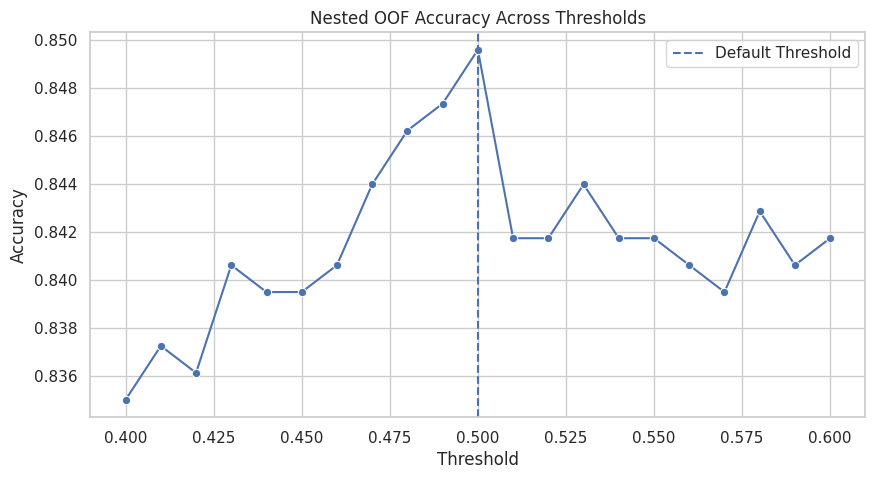

In [43]:
plt.figure(
    figsize=(10, 5)
)


sns.lineplot(

    data=threshold_df,

    x="Threshold",

    y="Accuracy",

    marker="o"
)


plt.axvline(

    0.5,

    linestyle="--",

    label="Default Threshold"
)


plt.title(
    "Nested OOF Accuracy Across Thresholds"
)


plt.legend()


plt.show()

# 14. Build Final Training and Test Features

For final model training:

### Training Dataset

Target-derived group features will be generated using cross-fitting.

Each training passenger receives group information generated without directly using their own target.

### Test Dataset

Group survival features will be generated using all labeled training passengers.

This allows test passengers to benefit from known relatives and ticket-group members in the training dataset.

The test target is never accessed.

In [44]:
final_train_features = (

    create_inner_cross_fitted_features(

        train_subset=
            train_struct,

        train_target=
            y,

        n_splits=5,

        random_state=42,

        smoothing=3.0
    )
)


final_test_features = (

    add_target_group_features(

        reference_df=
            train_struct,

        reference_y=
            y,

        target_df=
            test_struct,

        smoothing=3.0
    )
)


X_final = (

    final_train_features[
        advanced_features
    ]
)


X_test_final = (

    final_test_features[
        advanced_features
    ]
)


print(
    X_final.shape
)


print(
    X_test_final.shape
)

(891, 49)
(418, 49)


In [45]:
final_test_probabilities = {}

final_models = {}


for model_name, model in (

    candidate_models.items()
):

    print(
        f"Training final "
        f"{model_name}"
    )


    pipeline = Pipeline(

        steps=[

            (
                "preprocessor",

                create_preprocessor(
                    advanced_features
                )
            ),

            (
                "classifier",

                clone(
                    model
                )
            )
        ]
    )


    pipeline.fit(

        X_final,

        y
    )


    final_test_probabilities[
        model_name
    ] = (

        pipeline

        .predict_proba(

            X_test_final
        )[:, 1]
    )


    final_models[
        model_name
    ] = pipeline

Training final Logistic Regression
Training final Random Forest
Training final Extra Trees
Training final Gradient Boosting


In [46]:
ensemble_test_probability = (

    best_ensemble[
        "Weight A"
    ]

    *

    final_test_probabilities[

        best_ensemble[
            "Model A"
        ]
    ]

    +

    best_ensemble[
        "Weight B"
    ]

    *

    final_test_probabilities[

        best_ensemble[
            "Model B"
        ]
    ]

    +

    best_ensemble[
        "Weight C"
    ]

    *

    final_test_probabilities[

        best_ensemble[
            "Model C"
        ]
    ]
)


ensemble_test_prediction = (

    ensemble_test_probability

    >= 0.5

).astype(int)


print(
    "Predicted survivors:",
    ensemble_test_prediction.sum()
)


print(
    "Predicted non-survivors:",
    (
        ensemble_test_prediction
        == 0
    ).sum()
)

Predicted survivors: 148
Predicted non-survivors: 270


# 15. Validate Potential Post-Processing Rules

Before manually changing any test predictions, we should determine whether similar rules improve out-of-fold predictions.

We will evaluate a small number of candidate rules.

Examples include:

- Correcting highly confident demographic-group contradictions.
- Using strong family evidence.
- Using strong ticket evidence.

A rule will only be considered for test predictions if it improves or maintains nested OOF accuracy.

This prevents us from creating arbitrary leaderboard-specific corrections.

In [47]:
rule_features = (

    final_train_features.copy()
)


rule_features[
    "BasePrediction"
] = best_oof_prediction


rule_features[
    "BaseProbability"
] = best_oof_probability


rule_features[
    "TrueTarget"
] = y.values

In [48]:
family_rule_prediction = (

    best_oof_prediction.copy()
)


strong_family_survival = (

    (
        rule_features[
            "FamilyKnownCount"
        ]
        >= 2
    )

    &

    (
        rule_features[
            "FamilySurvivalSignal"
        ]
        >= 0.80
    )
)


strong_family_death = (

    (
        rule_features[
            "FamilyKnownCount"
        ]
        >= 2
    )

    &

    (
        rule_features[
            "FamilySurvivalSignal"
        ]
        <= 0.20
    )
)


family_rule_prediction[

    strong_family_survival.values

] = 1


family_rule_prediction[

    strong_family_death.values

] = 0


family_rule_accuracy = (

    accuracy_score(

        y,

        family_rule_prediction
    )
)


base_ensemble_accuracy = (

    accuracy_score(

        y,

        best_oof_prediction
    )
)


print(
    f"Base accuracy: "
    f"{base_ensemble_accuracy:.4f}"
)


print(
    f"Family-rule accuracy: "
    f"{family_rule_accuracy:.4f}"
)


print(
    "Predictions changed:",
    np.sum(

        family_rule_prediction

        !=

        best_oof_prediction
    )
)

Base accuracy: 0.8496
Family-rule accuracy: 0.8496
Predictions changed: 0


In [49]:
ticket_rule_prediction = (

    best_oof_prediction.copy()
)


strong_ticket_survival = (

    (
        rule_features[
            "TicketKnownCount"
        ]
        >= 2
    )

    &

    (
        rule_features[
            "TicketSurvivalSignal"
        ]
        >= 0.80
    )
)


strong_ticket_death = (

    (
        rule_features[
            "TicketKnownCount"
        ]
        >= 2
    )

    &

    (
        rule_features[
            "TicketSurvivalSignal"
        ]
        <= 0.20
    )
)


ticket_rule_prediction[

    strong_ticket_survival.values

] = 1


ticket_rule_prediction[

    strong_ticket_death.values

] = 0


ticket_rule_accuracy = (

    accuracy_score(

        y,

        ticket_rule_prediction
    )
)


print(
    f"Base accuracy: "
    f"{base_ensemble_accuracy:.4f}"
)


print(
    f"Ticket-rule accuracy: "
    f"{ticket_rule_accuracy:.4f}"
)


print(
    "Predictions changed:",
    np.sum(

        ticket_rule_prediction

        !=

        best_oof_prediction
    )
)

Base accuracy: 0.8496
Ticket-rule accuracy: 0.8496
Predictions changed: 0


# 16. Construct OOF-Supported Hybrid

The final hybrid submission will only apply a rule if that rule matched or improved the nested OOF accuracy.

This creates a simple safeguard:

> Do not modify predictions using a rule that made validation performance worse.

The pure nested ensemble will always be retained as a separate submission.

In [50]:
validated_hybrid_prediction = (

    ensemble_test_prediction.copy()
)


rules_applied = []


if family_rule_accuracy >= (
    base_ensemble_accuracy
):

    test_family_survival = (

        (
            final_test_features[
                "FamilyKnownCount"
            ]
            >= 2
        )

        &

        (
            final_test_features[
                "FamilySurvivalSignal"
            ]
            >= 0.80
        )
    )


    test_family_death = (

        (
            final_test_features[
                "FamilyKnownCount"
            ]
            >= 2
        )

        &

        (
            final_test_features[
                "FamilySurvivalSignal"
            ]
            <= 0.20
        )
    )


    validated_hybrid_prediction[

        test_family_survival.values

    ] = 1


    validated_hybrid_prediction[

        test_family_death.values

    ] = 0


    rules_applied.append(
        "Family Rule"
    )


if ticket_rule_accuracy >= (
    base_ensemble_accuracy
):

    test_ticket_survival = (

        (
            final_test_features[
                "TicketKnownCount"
            ]
            >= 2
        )

        &

        (
            final_test_features[
                "TicketSurvivalSignal"
            ]
            >= 0.80
        )
    )


    test_ticket_death = (

        (
            final_test_features[
                "TicketKnownCount"
            ]
            >= 2
        )

        &

        (
            final_test_features[
                "TicketSurvivalSignal"
            ]
            <= 0.20
        )
    )


    validated_hybrid_prediction[

        test_ticket_survival.values

    ] = 1


    validated_hybrid_prediction[

        test_ticket_death.values

    ] = 0


    rules_applied.append(
        "Ticket Rule"
    )


print(
    "Rules applied:",
    rules_applied
)


print(
    "Predictions changed from ensemble:",
    np.sum(

        validated_hybrid_prediction

        !=

        ensemble_test_prediction
    )
)

Rules applied: ['Family Rule', 'Ticket Rule']
Predictions changed from ensemble: 0


In [51]:
best_individual_model = (

    nested_results_df

    .iloc[0][
        "Model"
    ]
)


best_individual_prediction = (

    final_test_probabilities[

        best_individual_model
    ]

    >= 0.5

).astype(int)


print(
    "Best individual model:",
    best_individual_model
)

Best individual model: Gradient Boosting


# 17. Create a Stable Threshold Candidate

If the threshold analysis shows that a threshold near 0.5 performs consistently well, we may create one additional submission using the strongest nearby threshold.

We will not automatically use the single highest OOF threshold.

Instead, we will select the best threshold within the conservative range:

`0.47 to 0.53`

This reduces the risk of overfitting the classification threshold to OOF predictions.

In [52]:
conservative_thresholds = (

    threshold_df[

        threshold_df[
            "Threshold"
        ]
        .between(
            0.47,
            0.53
        )

    ]

    .sort_values(

        "Accuracy",

        ascending=False
    )
)


best_stable_threshold = (

    conservative_thresholds

    .iloc[0][
        "Threshold"
    ]
)


stable_threshold_prediction = (

    ensemble_test_probability

    >= best_stable_threshold

).astype(int)


print(
    "Selected stable threshold:",
    best_stable_threshold
)


print(
    "Differences from 0.5 threshold:",
    np.sum(

        stable_threshold_prediction

        !=

        ensemble_test_prediction
    )
)

Selected stable threshold: 0.5
Differences from 0.5 threshold: 0


In [53]:
def save_submission(
    predictions,
    filename
):

    submission = pd.DataFrame({

        "PassengerId":

            test_passenger_ids
            .astype(int),

        "Survived":

            np.asarray(
                predictions
            )
            .astype(int)
    })


    assert len(
        submission
    ) == len(
        test_raw
    )


    assert submission[
        "PassengerId"
    ].is_unique


    assert submission[
        "Survived"
    ].isna().sum() == 0


    assert set(

        submission[
            "Survived"
        ].unique()

    ).issubset(
        {0, 1}
    )


    path = (

        submissions_dir

        /

        filename
    )


    submission.to_csv(

        path,

        index=False
    )


    print(
        f"Saved: {path}"
    )


    return submission

In [54]:
submission_nested_ensemble = (

    save_submission(

        ensemble_test_prediction,

        "submission_phase12_nested_ensemble.csv"
    )
)

Saved: ../submissions/submission_phase12_nested_ensemble.csv


In [55]:
submission_validated_hybrid = (

    save_submission(

        validated_hybrid_prediction,

        "submission_phase12_validated_hybrid.csv"
    )
)

Saved: ../submissions/submission_phase12_validated_hybrid.csv


In [56]:
submission_stable_threshold = (

    save_submission(

        stable_threshold_prediction,

        "submission_phase12_stable_threshold.csv"
    )
)

Saved: ../submissions/submission_phase12_stable_threshold.csv


In [57]:
submission_best_individual = (

    save_submission(

        best_individual_prediction,

        "submission_phase12_best_individual.csv"
    )
)

Saved: ../submissions/submission_phase12_best_individual.csv


In [58]:
submission_comparison = pd.DataFrame({

    "Submission": [

        "Nested Ensemble",

        "Validated Hybrid",

        "Stable Threshold",

        "Best Individual"
    ],

    "Predicted Survivors": [

        ensemble_test_prediction.sum(),

        validated_hybrid_prediction.sum(),

        stable_threshold_prediction.sum(),

        best_individual_prediction.sum()
    ],

    "Differences vs Nested Ensemble": [

        0,

        np.sum(

            validated_hybrid_prediction

            !=

            ensemble_test_prediction
        ),

        np.sum(

            stable_threshold_prediction

            !=

            ensemble_test_prediction
        ),

        np.sum(

            best_individual_prediction

            !=

            ensemble_test_prediction
        )
    ]
})


submission_comparison

,Submission,Predicted Survivors,Differences vs Nested Ensemble
0,Nested Ensemble,148,0
1,Validated Hybrid,148,0
2,Stable Threshold,148,0
3,Best Individual,152,12


In [59]:
submission_predictions = {

    "Nested Ensemble":

        ensemble_test_prediction,

    "Validated Hybrid":

        validated_hybrid_prediction,

    "Stable Threshold":

        stable_threshold_prediction,

    "Best Individual":

        best_individual_prediction
}


pairwise_differences = []


submission_names = list(

    submission_predictions.keys()
)


for i in range(
    len(submission_names)
):

    for j in range(
        i + 1,
        len(submission_names)
    ):

        name_a = (

            submission_names[i]
        )


        name_b = (

            submission_names[j]
        )


        differences = np.sum(

            submission_predictions[
                name_a
            ]

            !=

            submission_predictions[
                name_b
            ]
        )


        pairwise_differences.append({

            "Submission A":
                name_a,

            "Submission B":
                name_b,

            "Different Predictions":
                differences
        })


pairwise_differences_df = (

    pd.DataFrame(
        pairwise_differences
    )
)


pairwise_differences_df

,Submission A,Submission B,Different Predictions
0,Nested Ensemble,Validated Hybrid,0
1,Nested Ensemble,Stable Threshold,0
2,Nested Ensemble,Best Individual,12
3,Validated Hybrid,Stable Threshold,0
4,Validated Hybrid,Best Individual,12
5,Stable Threshold,Best Individual,12


In [60]:
nested_results_df.to_csv(

    results_dir

    /

    "phase12_nested_model_results.csv",

    index=False
)


ensemble_search_df.to_csv(

    results_dir

    /

    "phase12_ensemble_search.csv",

    index=False
)


threshold_df.to_csv(

    results_dir

    /

    "phase12_threshold_analysis.csv",

    index=False
)


error_analysis.to_csv(

    results_dir

    /

    "phase12_oof_error_analysis.csv",

    index=False
)


error_by_role.to_csv(

    results_dir

    /

    "phase12_error_by_role.csv",

    index=False
)


submission_comparison.to_csv(

    results_dir

    /

    "phase12_submission_comparison.csv",

    index=False
)


pairwise_differences_df.to_csv(

    results_dir

    /

    "phase12_pairwise_submission_differences.csv",

    index=False
)


print(
    "Phase 12 results saved successfully."
)

Phase 12 results saved successfully.


In [61]:
print(
    "=" * 70
)

print(
    "PHASE 12 FINAL DIAGNOSTIC REPORT"
)

print(
    "=" * 70
)


print(
    "\n1. Nested Model Results"
)


display(

    nested_results_df.round(4)
)


print(
    "\n2. Best Ensemble"
)


display(
    best_ensemble
)


print(
    "\n3. Base Ensemble OOF Accuracy"
)


print(

    round(

        base_ensemble_accuracy,

        4
    )
)


print(
    "\n4. Family Rule Accuracy"
)


print(

    round(

        family_rule_accuracy,

        4
    )
)


print(
    "\n5. Ticket Rule Accuracy"
)


print(

    round(

        ticket_rule_accuracy,

        4
    )
)


print(
    "\n6. Rules Applied to Final Hybrid"
)


print(
    rules_applied
)


print(
    "\n7. Submission Comparison"
)


display(
    submission_comparison
)


print(
    "\n8. Pairwise Differences"
)


display(
    pairwise_differences_df
)

PHASE 12 FINAL DIAGNOSTIC REPORT

1. Nested Model Results


,Model,Nested OOF Accuracy,Nested OOF Log Loss,Fold Mean,Fold Std,Fold Min,Fold Max
0,Gradient Boosting,0.8474,0.3719,0.8474,0.0119,0.8258,0.8596
1,Extra Trees,0.8474,0.3801,0.8473,0.0122,0.8315,0.8659
2,Random Forest,0.8462,0.3740,0.8462,0.0150,0.8315,0.8708
3,Logistic Regression,0.8384,0.3854,0.8384,0.0159,0.8146,0.8596



2. Best Ensemble


Model A     Gradient Boosting
Weight A                  0.1
Model B           Extra Trees
Weight B                  0.8
Model C         Random Forest
Weight C                  0.1
Accuracy             0.849607
Log Loss              0.37628
Name: 0, dtype: object


3. Base Ensemble OOF Accuracy
0.8496

4. Family Rule Accuracy
0.8496

5. Ticket Rule Accuracy
0.8496

6. Rules Applied to Final Hybrid
['Family Rule', 'Ticket Rule']

7. Submission Comparison


,Submission,Predicted Survivors,Differences vs Nested Ensemble
0,Nested Ensemble,148,0
1,Validated Hybrid,148,0
2,Stable Threshold,148,0
3,Best Individual,152,12



8. Pairwise Differences


,Submission A,Submission B,Different Predictions
0,Nested Ensemble,Validated Hybrid,0
1,Nested Ensemble,Stable Threshold,0
2,Nested Ensemble,Best Individual,12
3,Validated Hybrid,Stable Threshold,0
4,Validated Hybrid,Best Individual,12
5,Stable Threshold,Best Individual,12
